# PatchTST — Short-Term Load Forecasting
## MENA-Grid Benchmark with Hijri Calendar + ERA5 Meteorological Features

**Architecture:** Channel-Independent Patch Transformer  
**Forecast target:** `y_{t+24}` — national load 24 h ahead (MW)  
**Dataset:** EPIAS Turkey hourly load + ERA5 weather, Jan 2018 – Dec 2025  
**Features:** Load lags · Gregorian · Hijri (Ramadan/Eid) · `temp_c` · `dewpoint_c` · `wind_speed` · `solar_rad`  
**Splits:** Train 2018–2022 · Val 2023 · Test 2024–2025

> *Paper §4.2 — PatchTST: P=16, S=8, 3 layers, 4 heads, d=128, MSE loss, AdamW lr=1e-4, cosine schedule, early stopping.*


## 1. Imports & Configuration

In [19]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [20]:


import math, time, warnings, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cpu


In [21]:
CFG = dict(
    # ── model ────────────────────────────────────────────────────────────
    context_len  = 168,   # L hours look-back  (ablation C: 96/168/336/720)
    forecast_len = 24,    # predict 24 h ahead
    patch_size   = 16,    # P
    patch_stride = 8,     # S  →  (168-16)//8 + 1 = 20 patches
    d_model      = 128,
    n_heads      = 4,
    n_layers     = 3,
    d_ff         = 256,
    dropout      = 0.1,
    # ── training ─────────────────────────────────────────────────────────
    batch_size   = 64,
    max_epochs   = 50,
    lr           = 1e-4,
    patience     = 7,
    weight_decay = 1e-4,
    # ── misc ─────────────────────────────────────────────────────────────
    target_col   = "actual_load",
    data_path    = "C:\\Users\\Shady\\Downloads\\Ramadan-Aware-Short-Term-Load-Forecasting-Benchmarking--main\\data\\processed\\final_training_set_v1.csv",
    ckpt_path    = "patchtst_best.pt",
)

NUM_PATCHES = (CFG["context_len"] - CFG["patch_size"]) // CFG["patch_stride"] + 1
print(f"Patches per window: {NUM_PATCHES}")

# ── Covariate groups (paper Table 1) ─────────────────────────────────────
COV_BASE = [
    # Gregorian
    "hour", "day_of_week", "month",
    # Hijri
    "is_ramadan", "is_eid", "day_of_ramadan",
    # Load features
    "load_lag_24h", "load_lag_168h",
    "load_rolling_mean_24h", "load_rolling_std_24h",
    "load_rolling_mean_168h", "load_rolling_std_168h",
    # Meteorological (ERA5) — new in v1 dataset
    "temp_c", "dewpoint_c", "wind_speed", "solar_rad",
]
# Cyclical sin/cos encodings added during preprocessing (see §2)
COV_CYCLICAL = [
    "hour_sin", "hour_cos",
    "day_of_week_sin", "day_of_week_cos",
    "month_sin", "month_cos",
]
COV_COLS = COV_BASE + COV_CYCLICAL
print(f"Total covariates: {len(COV_COLS)}")


Patches per window: 20
Total covariates: 22


## 2. Data Loading & Exploratory Analysis

In [22]:
df = pd.read_csv(CFG["data_path"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.set_index("timestamp").sort_index()

# ── Cyclical encodings ───────────────────────────────────────────────────
for col, period in [("hour", 24), ("day_of_week", 7), ("month", 12)]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

# ── Heatwave flag for regime analysis ────────────────────────────────────
# sustained temp >= 35°C for >= 3 consecutive days  (paper Table 3)
df["hot_day"]   = (df["temp_c"] >= 35).astype(int)
roll3           = df["hot_day"].rolling(72, min_periods=1).sum()   # 3 days = 72 h
df["is_heatwave"] = (roll3 >= 72).astype(int)

df[COV_COLS] = df[COV_COLS].fillna(0.0)

print(f"Shape         : {df.shape}")
print(f"Date range    : {df.index.min().date()} → {df.index.max().date()}")
print(f"Load range    : {df.actual_load.min():,.0f} – {df.actual_load.max():,.0f} MW")
print(f"Temp range    : {df.temp_c.min():.1f} – {df.temp_c.max():.1f} °C")
print(f"Ramadan hours : {df.is_ramadan.sum():,}  ({df.is_ramadan.mean()*100:.1f}%)")
print(f"Heatwave hrs  : {df.is_heatwave.sum():,}  ({df.is_heatwave.mean()*100:.1f}%)")
df.head()


Shape         : (70125, 25)
Date range    : 2018-01-01 → 2025-12-31
Load range    : 15,333 – 59,504 MW
Temp range    : -5.8 – 36.1 °C
Ramadan hours : 5,688  (8.1%)
Heatwave hrs  : 0  (0.0%)


,actual_load,is_ramadan,is_eid,day_of_ramadan,hour,day_of_week,month,load_lag_24h,load_lag_168h,load_rolling_mean_24h,...,wind_speed,solar_rad,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,hot_day,is_heatwave
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,23872.12,0,0,0,0,0,1,26147.83,26623.11,28925.96708,...,1.173892,0.0,0.000000,1.000000,0.0,1.0,0.5,0.866025,0,0
2018-01-01 01:00:00+00:00,23194.89,0,0,0,1,0,1,25677.70,26789.84,28831.14583,...,1.164122,0.0,0.258819,0.965926,0.0,1.0,0.5,0.866025,0,0
2018-01-01 02:00:00+00:00,23071.96,0,0,0,2,0,1,25533.06,27039.91,28727.69542,...,1.245200,0.0,0.500000,0.866025,0.0,1.0,0.5,0.866025,0,0
2018-01-01 03:00:00+00:00,23267.90,0,0,0,3,0,1,25761.81,28359.26,28625.14958,...,1.327444,0.0,0.707107,0.707107,0.0,1.0,0.5,0.866025,0,0
2018-01-01 04:00:00+00:00,23875.44,0,0,0,4,0,1,25833.86,31230.31,28521.23667,...,1.360890,0.0,0.866025,0.500000,0.0,1.0,0.5,0.866025,0,0


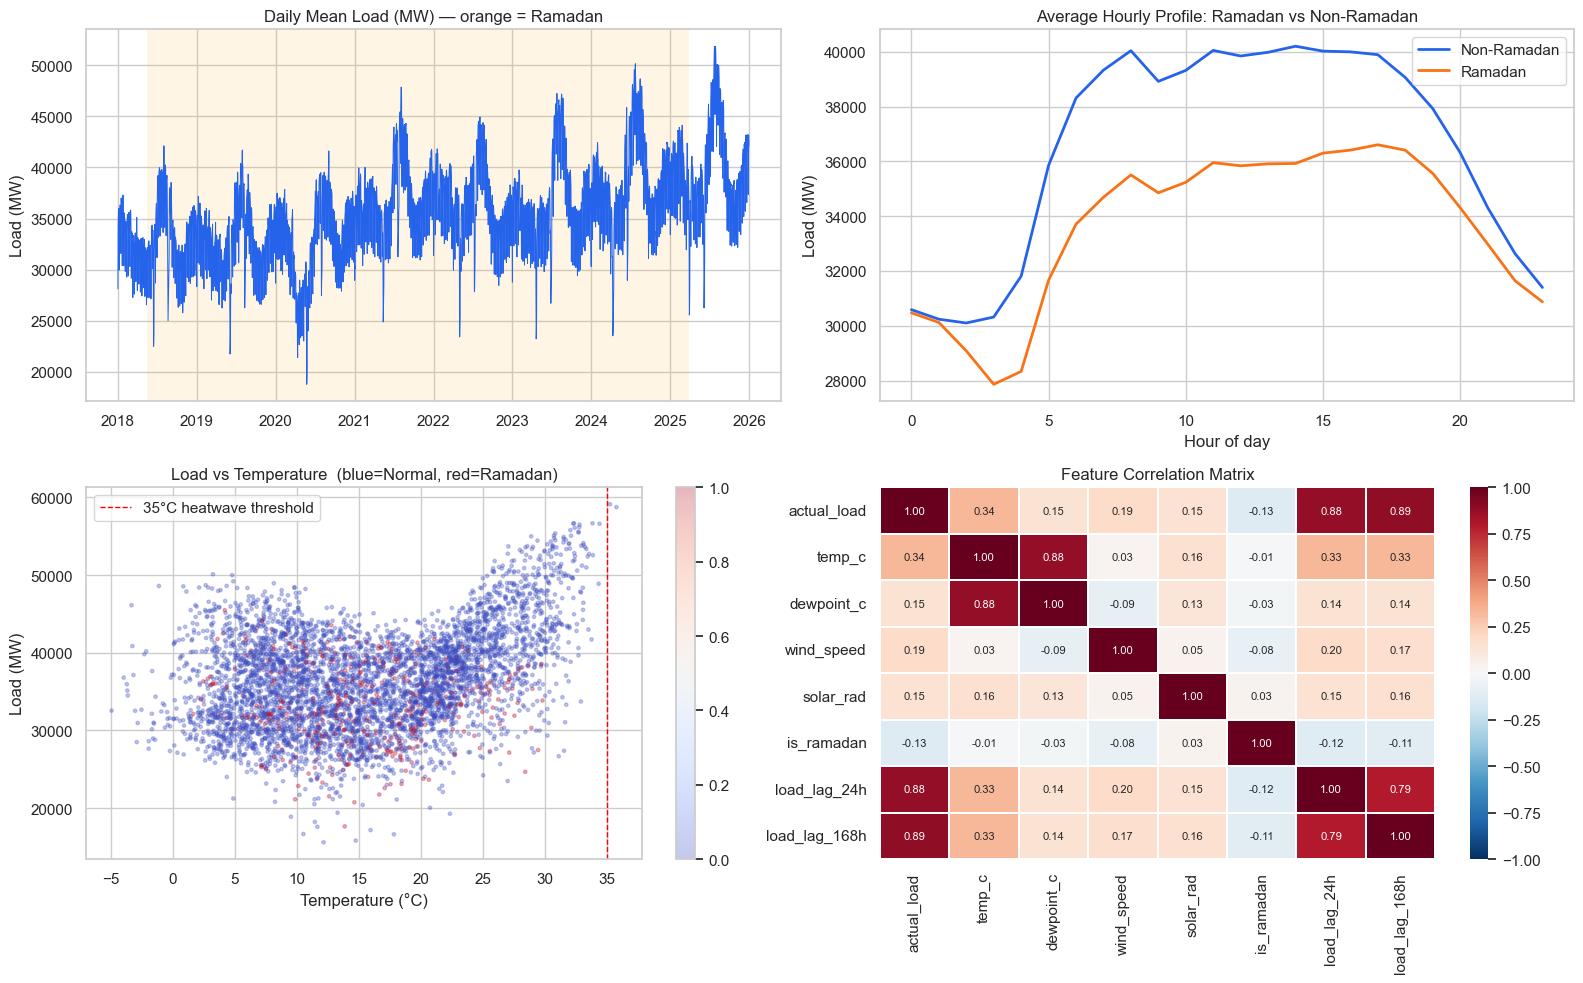

Saved eda_overview.png


In [23]:
# ── EDA: 4-panel overview ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Daily load — full series with Ramadan shading
daily = df["actual_load"].resample("D").mean()
axes[0,0].plot(daily.index, daily.values, lw=0.7, color="#2563eb")
for d in df[df["is_ramadan"]==1].resample("D").first().index:
    axes[0,0].axvspan(d, d + pd.Timedelta("1D"), alpha=0.10, color="orange", lw=0)
axes[0,0].set_title("Daily Mean Load (MW) — orange = Ramadan")
axes[0,0].set_ylabel("Load (MW)")

# 2. Hourly profile: Ramadan vs Non-Ramadan
for label, mask, color in [
    ("Non-Ramadan", df["is_ramadan"]==0, "#2563eb"),
    ("Ramadan",     df["is_ramadan"]==1, "#f97316"),
]:
    p = df[mask].groupby("hour")["actual_load"].mean()
    axes[0,1].plot(p.index, p.values, label=label, color=color, lw=2)
axes[0,1].set_title("Average Hourly Profile: Ramadan vs Non-Ramadan")
axes[0,1].set_xlabel("Hour of day"); axes[0,1].set_ylabel("Load (MW)")
axes[0,1].legend()

# 3. Load vs temperature scatter (coloured by Ramadan)
sample = df.sample(5000, random_state=42)
sc = axes[1,0].scatter(sample["temp_c"], sample["actual_load"],
                        c=sample["is_ramadan"], cmap="coolwarm",
                        alpha=0.3, s=6)
axes[1,0].axvline(35, color="red", ls="--", lw=1, label="35°C heatwave threshold")
axes[1,0].set_xlabel("Temperature (°C)"); axes[1,0].set_ylabel("Load (MW)")
axes[1,0].set_title("Load vs Temperature  (blue=Normal, red=Ramadan)")
axes[1,0].legend()
plt.colorbar(sc, ax=axes[1,0])

# 4. Correlation heatmap of key features
corr_cols = ["actual_load","temp_c","dewpoint_c","wind_speed","solar_rad",
             "is_ramadan","load_lag_24h","load_lag_168h"]
corr = df[corr_cols].corr()
sns.heatmap(corr, ax=axes[1,1], annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.3, annot_kws={"size":8})
axes[1,1].set_title("Feature Correlation Matrix")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved eda_overview.png")


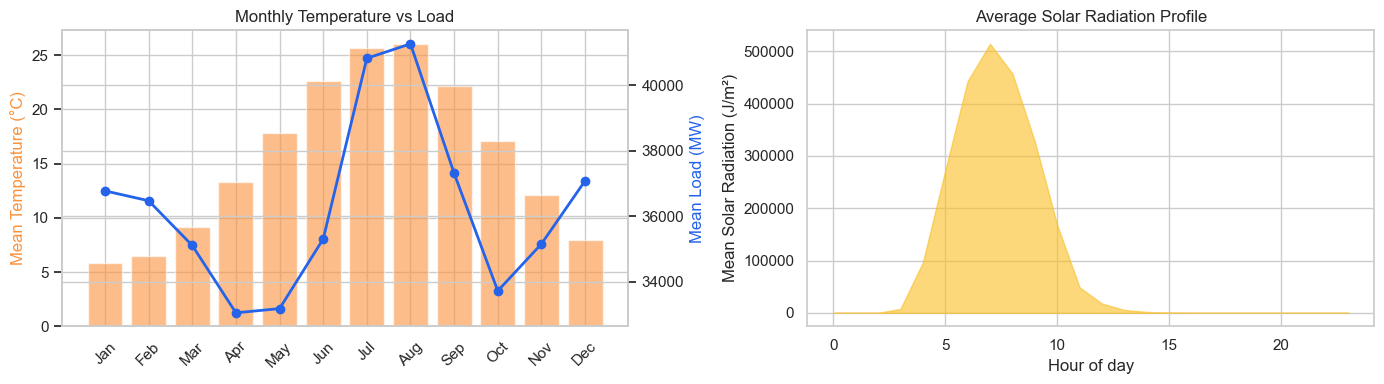

In [24]:
# ── Meteorological seasonality ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

monthly_temp = df.groupby("month")["temp_c"].mean()
monthly_load = df.groupby("month")["actual_load"].mean()
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

ax2 = axes[0].twinx()
axes[0].bar(range(1,13), monthly_temp.values, color="#fb923c", alpha=0.6, label="Temp (°C)")
ax2.plot(range(1,13), monthly_load.values, "o-", color="#2563eb", lw=2, label="Load (MW)")
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(months, rotation=45)
axes[0].set_ylabel("Mean Temperature (°C)", color="#fb923c")
ax2.set_ylabel("Mean Load (MW)", color="#2563eb")
axes[0].set_title("Monthly Temperature vs Load")

# Solar radiation daily profile
solar_profile = df.groupby("hour")["solar_rad"].mean()
axes[1].fill_between(solar_profile.index, solar_profile.values, alpha=0.6, color="#fbbf24")
axes[1].set_xlabel("Hour of day"); axes[1].set_ylabel("Mean Solar Radiation (J/m²)")
axes[1].set_title("Average Solar Radiation Profile")

plt.tight_layout()
plt.savefig("eda_met.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Train / Val / Test Splits

In [25]:
train_df = df[df.index.year <= 2022].copy()
val_df   = df[df.index.year == 2023].copy()
test_df  = df[df.index >= "2024-01-01"].copy()

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name:5s} : {split.index[0].date()} → {split.index[-1].date()} "
          f"| {len(split):>6,} rows "
          f"| Ramadan {split['is_ramadan'].mean()*100:.1f}% "
          f"| Heatwave {split['is_heatwave'].mean()*100:.1f}%")


Train : 2018-01-01 → 2022-12-31 | 43,824 rows | Ramadan 8.2% | Heatwave 0.0%
Val   : 2023-01-01 → 2023-12-31 |  8,760 rows | Ramadan 7.9% | Heatwave 0.0%
Test  : 2024-01-01 → 2025-12-31 | 17,541 rows | Ramadan 8.1% | Heatwave 0.0%


## 4. Dataset & DataLoaders

In [26]:
class LoadForecastDataset(Dataset):
    """
    Sliding-window dataset.
    Returns (x_load, x_cov, y):
      x_load : (context_len,)        — normalised load history
      x_cov  : (context_len, n_cov)  — all covariate channels
      y      : scalar                — normalised load 24 h ahead
    """

    def __init__(self, df, load_scaler, cov_scaler, cfg, cov_cols, fit_scalers=False):
        L, H = cfg["context_len"], cfg["forecast_len"]
        load_vals = df[cfg["target_col"]].values.astype(np.float32)
        cov_vals  = df[cov_cols].values.astype(np.float32)

        if fit_scalers:
            load_scaler.fit(load_vals.reshape(-1, 1))
            cov_scaler.fit(cov_vals)

        self.load_scaled = load_scaler.transform(load_vals.reshape(-1, 1)).flatten()
        self.cov_scaled  = cov_scaler.transform(cov_vals)
        self.cfg         = cfg
        self.indices     = list(range(L, len(load_vals) - H + 1))

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        t, L = self.indices[idx], self.cfg["context_len"]
        x_load = torch.tensor(self.load_scaled[t-L:t], dtype=torch.float32)
        x_cov  = torch.tensor(self.cov_scaled[t-L:t],  dtype=torch.float32)
        y      = torch.tensor(self.load_scaled[t + self.cfg["forecast_len"] - 1],
                              dtype=torch.float32)
        return x_load, x_cov, y


load_scaler = StandardScaler()
cov_scaler  = StandardScaler()

train_ds = LoadForecastDataset(train_df, load_scaler, cov_scaler, CFG, COV_COLS, fit_scalers=True)
val_ds   = LoadForecastDataset(val_df,   load_scaler, cov_scaler, CFG, COV_COLS)
test_ds  = LoadForecastDataset(test_df,  load_scaler, cov_scaler, CFG, COV_COLS)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG["batch_size"], shuffle=False, num_workers=0, pin_memory=True)

print(f"Train : {len(train_ds):,} samples")
print(f"Val   : {len(val_ds):,} samples")
print(f"Test  : {len(test_ds):,} samples")
x_l, x_c, y_ = train_ds[0]
print(f"x_load: {x_l.shape}  x_cov: {x_c.shape}  y: {y_.shape}")


Train : 43,633 samples
Val   : 8,569 samples
Test  : 17,350 samples
x_load: torch.Size([168])  x_cov: torch.Size([168, 22])  y: torch.Size([])


## 5. PatchTST Model

In [27]:
class PatchEmbedding(nn.Module):
    """(B, L) → (B, N_patches, d_model)"""
    def __init__(self, context_len, patch_size, patch_stride, d_model, dropout):
        super().__init__()
        self.patch_size   = patch_size
        self.patch_stride = patch_stride
        self.num_patches  = (context_len - patch_size) // patch_stride + 1
        self.proj = nn.Linear(patch_size, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.norm(self.proj(
            x.unfold(1, self.patch_size, self.patch_stride)
        )))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class PatchTST(nn.Module):
    """
    Channel-independent PatchTST (paper §4.2).
    Each channel (load + each covariate) is patch-embedded independently,
    then all embeddings are concatenated, projected to d_model, and passed
    through a Transformer encoder. A linear head produces the scalar forecast.
    """
    def __init__(self, cfg, n_cov):
        super().__init__()
        P, S, L  = cfg["patch_size"], cfg["patch_stride"], cfg["context_len"]
        d, drop  = cfg["d_model"], cfg["dropout"]
        n_patches = (L - P) // S + 1
        self.n_cov, self.n_patches = n_cov, n_patches

        self.load_embed   = PatchEmbedding(L, P, S, d, drop)
        self.cov_embeds   = nn.ModuleList([PatchEmbedding(L, P, S, d, drop) for _ in range(n_cov)])
        self.channel_proj = nn.Linear((1 + n_cov) * d, d)
        self.pos_enc      = PositionalEncoding(d, max_len=n_patches + 2, dropout=drop)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d, nhead=cfg["n_heads"], dim_feedforward=cfg["d_ff"],
            dropout=drop, batch_first=True, norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=cfg["n_layers"])
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_patches * d, d),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d, 1),
        )

    def forward(self, x_load, x_cov):
        embs = [self.load_embed(x_load)] + [self.cov_embeds[i](x_cov[:, :, i]) for i in range(self.n_cov)]
        x = self.channel_proj(torch.cat(embs, dim=-1))
        x = self.transformer(self.pos_enc(x))
        return self.head(x).squeeze(-1)


model = PatchTST(CFG, n_cov=len(COV_COLS)).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PatchTST | params: {n_params:,} | patches/window: {model.n_patches}")
print(f"Covariate channels: {len(COV_COLS)}")
print(model)


PatchTST | params: 1,158,273 | patches/window: 20
Covariate channels: 22
PatchTST(
  (load_embed): PatchEmbedding(
    (proj): Linear(in_features=16, out_features=128, bias=True)
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.1, inplace=False)
  )
  (cov_embeds): ModuleList(
    (0-21): 22 x PatchEmbedding(
      (proj): Linear(in_features=16, out_features=128, bias=True)
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.1, inplace=False)
    )
  )
  (channel_proj): Linear(in_features=2944, out_features=128, bias=True)
  (pos_enc): PositionalEncoding(
    (drop): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_featur

## 6. Training

In [28]:
def cosine_schedule(optimizer, n_warmup, n_total):
    def lr_lambda(step):
        if step < n_warmup:
            return step / max(1, n_warmup)
        progress = (step - n_warmup) / max(1, n_total - n_warmup)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def run_epoch(model, loader, optimizer, scheduler, criterion, device, train):
    model.train(train)
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for x_load, x_cov, y in loader:
            x_load, x_cov, y = x_load.to(device), x_cov.to(device), y.to(device)
            pred = model(x_load, x_cov)
            loss = criterion(pred, y)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
n_steps   = CFG["max_epochs"] * len(train_loader)
scheduler = cosine_schedule(optimizer, n_warmup=n_steps//10, n_total=n_steps)

history = {"train": [], "val": []}
best_val_loss, patience_cnt = float("inf"), 0

print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Time(s)':>8}")
print("-" * 42)

for epoch in range(1, CFG["max_epochs"] + 1):
    t0 = time.time()
    tr = run_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE, True)
    va = run_epoch(model, val_loader,   optimizer, scheduler, criterion, DEVICE, False)
    history["train"].append(tr); history["val"].append(va)

    improved = va < best_val_loss
    if improved:
        best_val_loss, patience_cnt = va, 0
        torch.save(model.state_dict(), CFG["ckpt_path"])
    else:
        patience_cnt += 1

    print(f"{epoch:>6}  {tr:>10.5f}  {va:>10.5f}  {time.time()-t0:>8.1f}{'  ✓' if improved else ''}")
    if patience_cnt >= CFG["patience"]:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest val MSE: {best_val_loss:.5f}")


 Epoch   Train MSE     Val MSE   Time(s)
------------------------------------------
     1     0.30179     0.10640     152.0  ✓
     2     0.09196     0.09149     108.1  ✓
     3     0.06749     0.07021     103.3  ✓
     4     0.05508     0.08410     100.6
     5     0.04548     0.07270     102.5
     6     0.03908     0.07002     100.5  ✓
     7     0.03275     0.08162     100.8
     8     0.02849     0.07658     101.1
     9     0.02497     0.07635     101.4
    10     0.02278     0.07067     100.8
    11     0.02118     0.08051     101.3
    12     0.02022     0.07663     100.8
    13     0.01883     0.08550     102.5

Early stopping at epoch 13.

Best val MSE: 0.07002


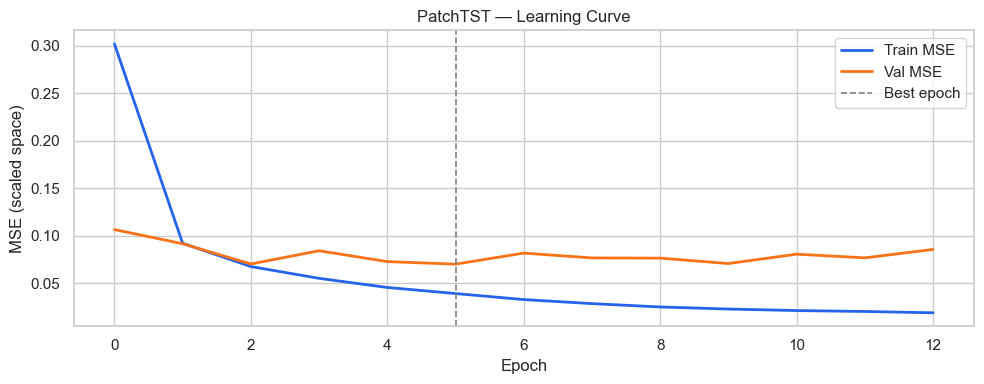

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train"], label="Train MSE", color="#2563eb", lw=2)
ax.plot(history["val"],   label="Val MSE",   color="#f97316", lw=2)
ax.axvline(np.argmin(history["val"]), ls="--", color="gray", lw=1.2, label="Best epoch")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled space)")
ax.set_title("PatchTST — Learning Curve"); ax.legend()
plt.tight_layout()
plt.savefig("learning_curve.png", dpi=150, bbox_inches="tight"); plt.show()


## 7. Test-Set Inference

In [30]:
model.load_state_dict(torch.load(CFG["ckpt_path"], map_location=DEVICE))
model.eval()

preds_sc, targets_sc = [], []
with torch.no_grad():
    for x_load, x_cov, y in test_loader:
        preds_sc.append(model(x_load.to(DEVICE), x_cov.to(DEVICE)).cpu().numpy())
        targets_sc.append(y.numpy())

y_pred = load_scaler.inverse_transform(np.concatenate(preds_sc).reshape(-1,1)).flatten()
y_true = load_scaler.inverse_transform(np.concatenate(targets_sc).reshape(-1,1)).flatten()

# Seasonal-naive baseline: same hour last week (lag-168)
naive_sc = np.array([
    test_ds.load_scaled[max(0, i - CFG["context_len"] - CFG["forecast_len"] + 1 - 168)]
    for i in test_ds.indices
])
y_naive = load_scaler.inverse_transform(naive_sc.reshape(-1,1)).flatten()

# Align to timestamps
test_aligned = test_df.iloc[[i - CFG["context_len"] for i in test_ds.indices]].copy()
test_aligned["y_pred"]  = y_pred
test_aligned["y_true"]  = y_true
test_aligned["y_naive"] = y_naive

print(f"Test predictions: {len(y_pred):,}")
test_aligned[["y_true","y_pred","y_naive"]].describe().round(1)


Test predictions: 17,350


,y_true,y_pred,y_naive
count,17350.0,17350.0,17350.0
mean,39664.5,39402.4,39422.2
std,6561.1,6041.0,6698.7
min,20062.4,19195.7,20062.4
25%,34399.9,34326.8,34162.5
50%,39829.5,39814.0,39644.4
75%,43998.7,43889.0,43787.7
max,59503.7,54763.1,59503.7


## 8. Evaluation Metrics (Paper §5)

In [31]:
def compute_metrics(y_true, y_pred, y_naive=None):
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mase = mae / np.mean(np.abs(y_true - y_naive)) if y_naive is not None else np.nan
    return dict(MAE=round(mae,2), MAPE=round(mape,3), RMSE=round(rmse,2), MASE=round(mase,4))

overall = compute_metrics(y_true, y_pred, y_naive)
print("── Overall Test Metrics ──────────────────────────────────────────")
for k, v in overall.items():
    print(f"  {k:<6}: {v}")


── Overall Test Metrics ──────────────────────────────────────────
  MAE   : 1353.8699951171875
  MAPE  : 3.368000030517578
  RMSE  : 1930.5999755859375
  MASE  : 0.2799000144004822


### 8.1 Regime-Conditional Metrics (Paper Table 3)

In [32]:
def regime_metrics(df_aligned, y_true, y_pred, y_naive):
    """
    Stratify by four regimes (paper Table 3):
      Normal   — non-Ramadan, non-heatwave
      Ramadan  — is_ramadan == 1
      Heatwave — non-Ramadan, is_heatwave == 1  (temp_c >= 35 for >= 3 days)
      Compound — Ramadan AND is_heatwave == 1
    """
    ram = df_aligned["is_ramadan"].values.astype(bool)
    hot = df_aligned["is_heatwave"].values.astype(bool) if "is_heatwave" in df_aligned.columns           else np.zeros(len(df_aligned), bool)

    regimes = {
        "Normal"  : (~ram) & (~hot),
        "Ramadan" : ram & (~hot),
        "Heatwave": (~ram) & hot,
        "Compound": ram & hot,
    }
    rows = []
    for name, mask in regimes.items():
        if mask.sum() == 0: continue
        m = compute_metrics(y_true[mask], y_pred[mask], y_naive[mask])
        m.update({"Regime": name, "N": int(mask.sum())})
        rows.append(m)
    return pd.DataFrame(rows).set_index("Regime")


reg_metrics = regime_metrics(test_aligned, y_true, y_pred, y_naive)
print("── Regime-Conditional Metrics ────────────────────────────────────")
display(reg_metrics.style
        .background_gradient(cmap="YlOrRd", axis=0, subset=["MAE","MAPE","RMSE","MASE"])
        .format({"MAE":"{:.1f}","MAPE":"{:.2f}%","RMSE":"{:.1f}","MASE":"{:.4f}","N":"{:,}"}))


── Regime-Conditional Metrics ────────────────────────────────────


,MAE,MAPE,RMSE,MASE,N
Regime,,,,,
Normal,1343.9,3.27%,1915.5,0.2798,"15,934"
Ramadan,1466.4,4.46%,2092.6,0.2804,"1,416"


## 9. Forecast Visualisations

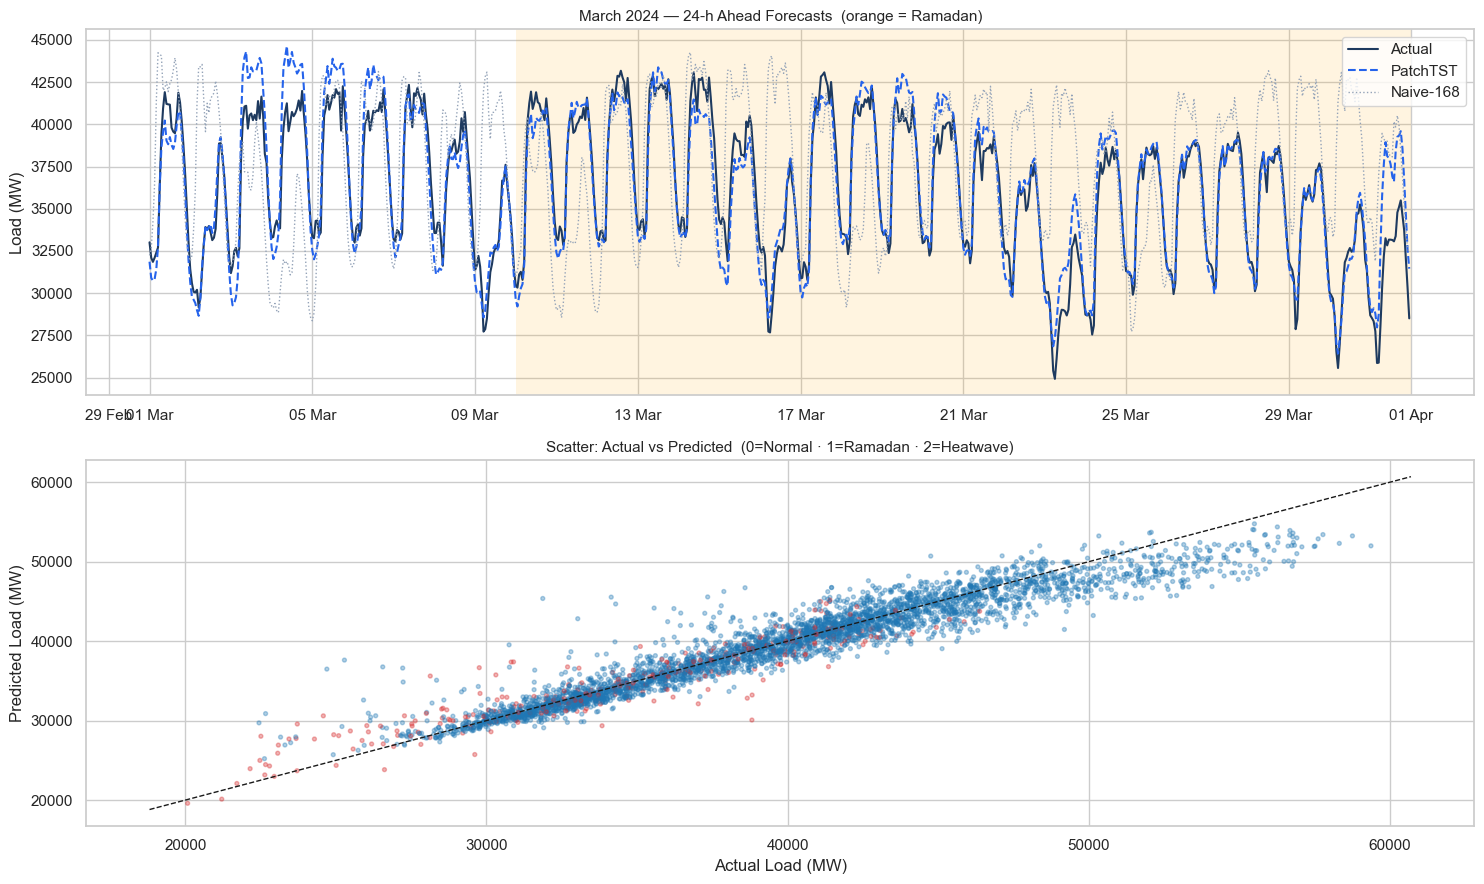

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# Panel A: one Ramadan-spanning month
window = test_aligned["2024-03-01":"2024-03-31"]
axes[0].plot(window.index, window["y_true"],  label="Actual",    color="#1e3a5f", lw=1.5)
axes[0].plot(window.index, window["y_pred"],  label="PatchTST",  color="#2563eb", lw=1.5, ls="--")
axes[0].plot(window.index, window["y_naive"], label="Naive-168", color="#94a3b8", lw=1, ls=":")
for d in window[window["is_ramadan"]==1].resample("D").first().index:
    axes[0].axvspan(d, d + pd.Timedelta("1D"), alpha=0.12, color="orange", lw=0)
axes[0].set_title("March 2024 — 24-h Ahead Forecasts  (orange = Ramadan)", fontsize=11)
axes[0].set_ylabel("Load (MW)"); axes[0].legend(loc="upper right")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Panel B: scatter coloured by regime
regime_color = np.where(test_aligned["is_ramadan"]==1, 1,
               np.where(test_aligned["is_heatwave"]==1, 2, 0))                if "is_heatwave" in test_aligned.columns else test_aligned["is_ramadan"].values
idx_s = np.random.choice(len(y_true), min(4000, len(y_true)), replace=False)
sc = axes[1].scatter(y_true[idx_s], y_pred[idx_s],
                     c=regime_color[idx_s], cmap="tab10", vmin=0, vmax=3,
                     alpha=0.35, s=8)
lims = [min(y_true.min(), y_pred.min())*0.98, max(y_true.max(), y_pred.max())*1.02]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("Actual Load (MW)"); axes[1].set_ylabel("Predicted Load (MW)")
axes[1].set_title("Scatter: Actual vs Predicted  (0=Normal · 1=Ramadan · 2=Heatwave)", fontsize=11)

plt.tight_layout()
plt.savefig("forecast_visual.png", dpi=150, bbox_inches="tight"); plt.show()


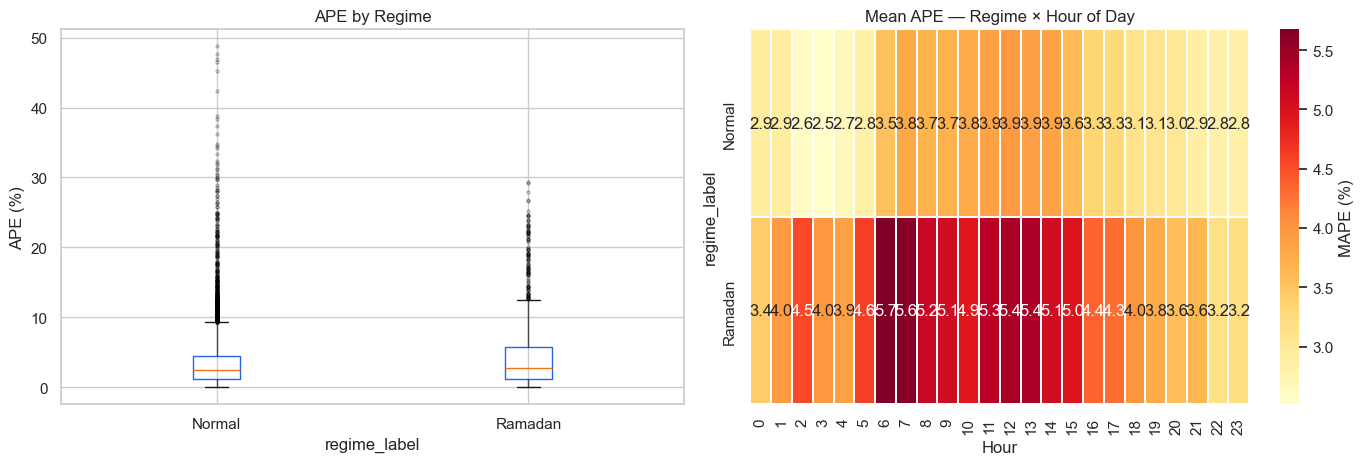

In [34]:
# ── Error heatmap: regime × hour ─────────────────────────────────────────
test_aligned["ape"] = (
    (test_aligned["y_pred"] - test_aligned["y_true"]).abs()
    / test_aligned["y_true"].abs() * 100
)
test_aligned["regime_label"] = "Normal"
test_aligned.loc[test_aligned["is_ramadan"]==1, "regime_label"] = "Ramadan"
if "is_heatwave" in test_aligned.columns:
    test_aligned.loc[(test_aligned["is_heatwave"]==1) & (test_aligned["is_ramadan"]==0),
                     "regime_label"] = "Heatwave"
    test_aligned.loc[(test_aligned["is_heatwave"]==1) & (test_aligned["is_ramadan"]==1),
                     "regime_label"] = "Compound"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
test_aligned.boxplot(column="ape", by="regime_label", ax=axes[0],
                     boxprops=dict(color="#2563eb"), medianprops=dict(color="#f97316"),
                     flierprops=dict(ms=2, alpha=0.3))
plt.sca(axes[0]); plt.title("APE by Regime"); plt.suptitle(""); axes[0].set_ylabel("APE (%)")

# Heatmap
pivot = test_aligned.copy()
pivot["hour_"] = pivot.index.hour
hmap = pivot.groupby(["regime_label","hour_"])["ape"].mean().unstack("hour_")
sns.heatmap(hmap, ax=axes[1], cmap="YlOrRd", annot=True, fmt=".1f",
            linewidths=0.3, cbar_kws={"label":"MAPE (%)"})
axes[1].set_title("Mean APE — Regime × Hour of Day"); axes[1].set_xlabel("Hour")

plt.tight_layout()
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight"); plt.show()


## 10. Ablation A — Ramadan Indicator Inclusion (Paper §6A)

Re-train with all Hijri columns zeroed; compare regime-level metrics to quantify the marginal value of Ramadan-awareness.


In [35]:
def train_model(train_df, val_df, test_df, cov_cols, cfg, ckpt, tag=""):
    """Compact training wrapper used for all ablations."""
    ls, cs = StandardScaler(), StandardScaler()
    tr_ds = LoadForecastDataset(train_df, ls, cs, cfg, cov_cols, fit_scalers=True)
    va_ds = LoadForecastDataset(val_df,   ls, cs, cfg, cov_cols)
    te_ds = LoadForecastDataset(test_df,  ls, cs, cfg, cov_cols)
    tr_ld = DataLoader(tr_ds, batch_size=cfg["batch_size"], shuffle=True,  num_workers=0)
    va_ld = DataLoader(va_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=cfg["batch_size"], shuffle=False, num_workers=0)

    m   = PatchTST(cfg, n_cov=len(cov_cols)).to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    n   = cfg["max_epochs"] * len(tr_ld)
    sch = cosine_schedule(opt, n_warmup=n//10, n_total=n)
    cri = nn.MSELoss()
    best, pat = float("inf"), 0

    for ep in range(1, cfg["max_epochs"] + 1):
        run_epoch(m, tr_ld, opt, sch, cri, DEVICE, True)
        va = run_epoch(m, va_ld, opt, sch, cri, DEVICE, False)
        if va < best: best, pat = va, 0; torch.save(m.state_dict(), ckpt)
        else: pat += 1
        if pat >= cfg["patience"]: break

    m.load_state_dict(torch.load(ckpt, map_location=DEVICE)); m.eval()
    ps, ys = [], []
    with torch.no_grad():
        for xl, xc, y in te_ld:
            ps.append(m(xl.to(DEVICE), xc.to(DEVICE)).cpu().numpy()); ys.append(y.numpy())

    yp = ls.inverse_transform(np.concatenate(ps).reshape(-1,1)).flatten()
    yt = ls.inverse_transform(np.concatenate(ys).reshape(-1,1)).flatten()
    naive_sc = np.array([
        te_ds.load_scaled[max(0, i - cfg["context_len"] - cfg["forecast_len"] + 1 - 168)]
        for i in te_ds.indices
    ])
    yn = ls.inverse_transform(naive_sc.reshape(-1,1)).flatten()
    aligned = test_df.iloc[[i - cfg["context_len"] for i in te_ds.indices]].copy()
    aligned["y_pred"] = yp; aligned["y_true"] = yt; aligned["y_naive"] = yn
    print(f"  [{tag}] val_best={best:.5f}  → {compute_metrics(yt,yp,yn)}")
    return aligned, yp, yt, yn


In [36]:
# Zero out Hijri columns only
df_no_hijri = df.copy()
for c in ["is_ramadan", "is_eid", "day_of_ramadan"]:
    df_no_hijri[c] = 0

train_nh = df_no_hijri[df_no_hijri.index.year <= 2022]
val_nh   = df_no_hijri[df_no_hijri.index.year == 2023]
test_nh  = df_no_hijri[df_no_hijri.index >= "2024-01-01"]

print("Ablation A: WITHOUT Hijri features …")
aligned_nh, yp_nh, yt_nh, yn_nh = train_model(
    train_nh, val_nh, test_nh, COV_COLS, CFG, "patchtst_no_hijri.pt", tag="no-Hijri"
)


Ablation A: WITHOUT Hijri features …
  [no-Hijri] val_best=0.06341  → {'MAE': np.float32(1360.35), 'MAPE': np.float32(3.337), 'RMSE': np.float32(1973.24), 'MASE': np.float32(0.2812)}


── Ablation A: Δ Metrics (With Hijri − Without Hijri) ───────────
  Negative Δ = Hijri features improve accuracy


,ΔMAE,ΔMAPE,ΔRMSE,ΔMASE,verdict
Regime,,,,,
Normal,-16.5,-0.066,-57.7,-0.0014,✓ Hijri helps
Ramadan,nan,nan,nan,nan,✗ neutral/hurts


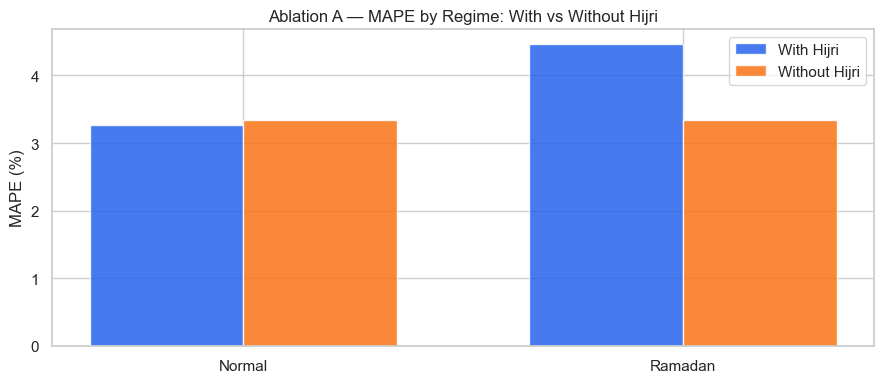

In [37]:
rm_with    = regime_metrics(test_aligned, y_true, y_pred, y_naive)
rm_without = regime_metrics(aligned_nh,  yt_nh,  yp_nh,  yn_nh)

delta = rm_with[["MAE","MAPE","RMSE","MASE"]] - rm_without[["MAE","MAPE","RMSE","MASE"]]
delta.columns = [f"Δ{c}" for c in delta.columns]
delta["verdict"] = delta["ΔMAE"].apply(lambda x: "✓ Hijri helps" if x < 0 else "✗ neutral/hurts")

print("── Ablation A: Δ Metrics (With Hijri − Without Hijri) ───────────")
print("  Negative Δ = Hijri features improve accuracy")
display(delta.style
        .background_gradient(cmap="RdYlGn_r", axis=0, subset=["ΔMAE","ΔMAPE","ΔRMSE"])
        .format({"ΔMAE":"{:.1f}","ΔMAPE":"{:.3f}","ΔRMSE":"{:.1f}","ΔMASE":"{:.4f}"}))

# Bar chart
fig, ax = plt.subplots(figsize=(9,4))
x, w = np.arange(len(rm_with)), 0.35
ax.bar(x-w/2, rm_with["MAPE"],    w, label="With Hijri",    color="#2563eb", alpha=0.85)
ax.bar(x+w/2, rm_without["MAPE"], w, label="Without Hijri", color="#f97316", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(rm_with.index)
ax.set_ylabel("MAPE (%)"); ax.set_title("Ablation A — MAPE by Regime: With vs Without Hijri")
ax.legend(); plt.tight_layout()
plt.savefig("ablation_hijri.png", dpi=150, bbox_inches="tight"); plt.show()


## 11. Ablation B — Heatwave × Ramadan Interaction Feature (Paper §6B)

In [38]:
# Add compound interaction feature: is_ramadan * temp_c
df_interact = df.copy()
df_interact["ramadan_x_temp"] = df_interact["is_ramadan"] * df_interact["temp_c"]
cov_interact = COV_COLS + ["ramadan_x_temp"]

train_ix = df_interact[df_interact.index.year <= 2022]
val_ix   = df_interact[df_interact.index.year == 2023]
test_ix  = df_interact[df_interact.index >= "2024-01-01"]

print("Ablation B: WITH Ramadan × Temp interaction feature …")
aligned_ix, yp_ix, yt_ix, yn_ix = train_model(
    train_ix, val_ix, test_ix, cov_interact,
    {**CFG}, "patchtst_interact.pt", tag="interact"
)

rm_interact = regime_metrics(aligned_ix, yt_ix, yp_ix, yn_ix)
delta_b = rm_interact[["MAE","MAPE","RMSE","MASE"]] - rm_with[["MAE","MAPE","RMSE","MASE"]]
delta_b.columns = [f"Δ{c}" for c in delta_b.columns]
print("\n── Ablation B: Δ Metrics (Interaction − Base) ───────────────────")
print("  Negative Δ = interaction feature helps")
display(delta_b.style
        .background_gradient(cmap="RdYlGn_r", axis=0, subset=["ΔMAE","ΔMAPE","ΔRMSE"])
        .format({"ΔMAE":"{:.1f}","ΔMAPE":"{:.3f}","ΔRMSE":"{:.1f}","ΔMASE":"{:.4f}"}))


Ablation B: WITH Ramadan × Temp interaction feature …
  [interact] val_best=0.06399  → {'MAE': np.float32(1393.06), 'MAPE': np.float32(3.372), 'RMSE': np.float32(2034.68), 'MASE': np.float32(0.288)}

── Ablation B: Δ Metrics (Interaction − Base) ───────────────────
  Negative Δ = interaction feature helps


,ΔMAE,ΔMAPE,ΔRMSE,ΔMASE
Regime,,,,
Normal,51.0,0.043,124.8,0.0106
Ramadan,-94.0,-0.438,-123.1,-0.0179


## 12. Ablation C — Context-Length Sensitivity (Paper §6C)

In [ ]:
CONTEXT_LENGTHS = [96, 168, 336, 720]
cl_records = []

for L in CONTEXT_LENGTHS:
    print(f"\n── L={L} ──")
    cfg_L = {**CFG, "context_len": L}
    aligned_L, yp_L, yt_L, yn_L = train_model(
        train_df, val_df, test_df, COV_COLS, cfg_L, f"patchtst_L{L}.pt", tag=f"L={L}"
    )
    m = compute_metrics(yt_L, yp_L, yn_L)
    m["context_len"] = L
    # Ramadan-only metrics
    ram_mask = aligned_L["is_ramadan"].values.astype(bool)
    if ram_mask.sum() > 0:
        mr = compute_metrics(yt_L[ram_mask], yp_L[ram_mask], yn_L[ram_mask])
        m["Ramadan_MAPE"] = mr["MAPE"]
    cl_records.append(m)

cl_summary = pd.DataFrame(cl_records).set_index("context_len")
print("\n── Context-Length Ablation ───────────────────────────────────────")
display(cl_summary.style
        .highlight_min(axis=0, color="#bbf7d0")
        .format({"MAE":"{:.1f}","MAPE":"{:.3f}","RMSE":"{:.1f}",
                 "MASE":"{:.4f}","Ramadan_MAPE":"{:.3f}"}))



── L=96 ──


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (metric, ylabel) in enumerate([
    ("MAPE", "MAPE (%)"), ("MAE", "MAE (MW)"), ("Ramadan_MAPE", "Ramadan MAPE (%)")
]):
    if metric not in cl_summary.columns: continue
    axes[i].plot(cl_summary.index, cl_summary[metric], "o-",
                 color="#2563eb", lw=2, ms=8)
    axes[i].axvline(168, ls="--", color="gray", lw=1, label="L=168 (default)")
    axes[i].set_xticks(CONTEXT_LENGTHS)
    axes[i].set_xlabel("Context length L (hours)")
    axes[i].set_ylabel(ylabel)
    axes[i].set_title(f"Ablation C — {metric}")
    axes[i].legend()

plt.tight_layout()
plt.savefig("ablation_context.png", dpi=150, bbox_inches="tight"); plt.show()


## 13. Results Summary

In [ ]:
print("=" * 65)
print("PatchTST — Final Results  |  dataset: final_training_set_v1")
print("=" * 65)
print("\nOverall Test Metrics:")
for k, v in overall.items(): print(f"  {k:<6}: {v}")
print("\nRegime-Conditional:")
print(reg_metrics.to_string())
print("\nAblation A — Δ (With Hijri − Without Hijri):")
print(delta.drop(columns=["verdict"], errors="ignore").to_string())
print("\nAblation C — Context Length sweep:")
print(cl_summary.to_string())
print("=" * 65)
